---
title: Get started with the Executor primitive
description: How to use the Executor primitive in Qiskit Runtime.

---

# Get started with the Executor primitive

{/*
  DO NOT EDIT THIS CELL!!!
  This cell's content is generated automatically by a script. Anything you add
  here will be removed next time the notebook is run. To add new content, create
  a new cell before or after this one.
*/}

<details>
<summary><b>Package versions</b></summary>

The code on this page was developed using the following requirements.
We recommend using these versions or newer.

```
qiskit[all]~=2.3.0
qiskit-ibm-runtime~=0.43.1
```
</details>

Similar to the [Sampler](/docs/guides/get-started-with-sampler) primitive, Executor samples output registers from quantum circuit executions, but it does not have any built in error suppression or mitigation. Instead, it's part of the [directed execution model](/docs/guides/directed-execution-model) that provides the ingredients to capture design intents on the client side, and shifts the costly generation of circuit variants to the server side. Executor follows the directives provided in circuit annotations and options, generates and binds parameter values, executes the bound circuits on the hardware, and returns the execution results and metadata. It does not make any implicit decisions for you and gives you full control and transparency.

<Admonition type="note">
The Qiskit package does not yet have a base class for the Executor primitive.
</Admonition>

## Before you begin

Before using the Executor primitive, you must install Samplomatic, as shown in the following code block.  For more information, see the [Samplomatic documentation](https://qiskit.github.io/samplomatic).


In [12]:
# Install Samplomatic
pip install samplomatic

# For visualization support, include the visualization dependencies.
# pip install samplomatic[vis]

SyntaxError: invalid syntax (3436021115.py, line 1)


## Steps to use the Executor primitive

### 1. Initialize the account

Because Qiskit Runtime is a managed service, you first need to initialize your account. You can then select the QPU you want to use to calculate the expectation value.

Follow the steps in the [Set up your IBM Cloud&reg; account](/docs/guides/cloud-setup) if you don't already have an account.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, Executor
from qiskit_ibm_runtime.quantum_program import QuantumProgram
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from samplomatic.transpiler import generate_boxing_pass_manager
from samplomatic import build

# Initialize the service and choose a backend
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

In [2]:
print(backend)

<IBMBackend('ibm_pittsburgh')>


### 2. Create and transpile a circuit

You need at least one circuit to use the Executor primitive.  It can optionally have observables and paramaters.

In [3]:
# Generate the circuit
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)
circuit.cz(0, 1)
circuit.h(1)

# Using `measure_all` automatically creates the necessary
# classical registers.
circuit.measure_all()

The circuit needs to be transformed to only use instructions supported by the QPU (referred to as *instruction set architecture (ISA)* circuits). Use the transpiler to do this.

In [4]:
# Transpile the circuit
preset_pass_manager = generate_preset_pass_manager(
    backend=backend, optimization_level=0
)
isa_circuit = preset_pass_manager.run(circuit)

### 3. Initialize a `QuantumProgram`

Initialize a `QuantumProgram` with your workload. A `QuantumProgram` is made up of `QuantumProgramItems`. Typically, each item consists of a circuit, a set of parameter values, and possibly a `Samplex` to randomize those parameter values. For full details, see [Executor inputs and outputs](/docs/guides/executor-input-output).

The following cell initializes a `QuantumProgram` and specifies to perform 25 shots. Next, it appends the transpiled target circuit.

In [5]:
# Initialize an empty program
program = QuantumProgram(shots=25)

# Append the circuit to the program
program.append_circuit_item(isa_circuit)

### 4. Optional: Group gates and measurements into annotated boxes

Grouping instructions into boxes and annotating them is the primary way to specify your intent. In the following example, we use `generate_boxing_pass_manager` and its twirling parameters to group two-qubit gates and measurements into boxes and apply twirling annotation.

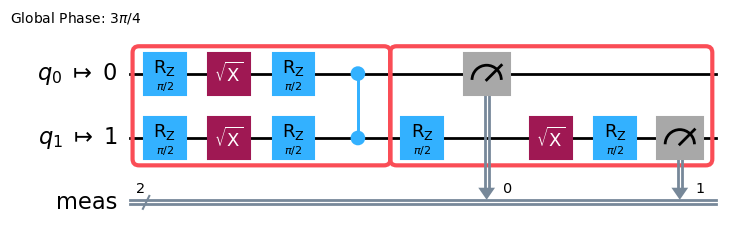

In [13]:
# Generate a boxing pass manager to group gates
# and measurements into boxes and add
# a`Twirl` annotation.
boxes_pm = generate_boxing_pass_manager(
    # Add gate twirling
    enable_gates=True,
    # Add measurement twirling
    enable_measures=True,
)

boxed_circuit = preset_pass_manager.run(isa_circuit)
boxed_circuit.draw("mpl")

### 5. Optional: Build a template and samplex, and add them to the program

Next, use the Samplomatic [build](https://qiskit.github.io/samplomatic/api/auto/samplomatic.build.html#samplomatic.build) method to generate the _template circuit_ and _samplex_ pair. The template circuit is structurally equivalent to original circuit. However, its single-qubit gates are replaced by parameterized gates in order to implement the prescribed annotations (gate and measurement twirling, in this example). The samplex encodes all the information required to generate randomized parameters for the template circuit.

After generating the template circuit and samplex pair, use the `append_samplex_item` method to add the pair to the program. 

See the Samplomatic [API](https://qiskit.github.io/samplomatic/api/index.html) documentation for full details about `samplomatic.samplex.Samplex` and its arguments.

In [ ]:
# Build the template circuit and the samplex
template_circuit, samplex = build(boxed_circuit)

# Append the template circuit and samplex as a `samplex_item`
program.append_samplex_item(
    template_circuit,
    samplex=samplex,
    shape=(num_randomizations := 20,),
)

### 6. Invoke Executor and get results

Run the `QuantumProgram` on an IBM&reg; backend by using the `Executor` primitive with default options. See [Executor options](/docs/guides/executor-options) to learn about the available options.

In [8]:
# Initialize an Executor with the default options
executor = Executor(mode=backend)

# Submit the job
job = executor.run(program)
job

<RuntimeJobV2('d7p781b9ak2c739rd1og', 'executor')>

In [9]:
# Retrieve the result
result = job.result()

The result is of type [`QuantumProgramResult`](https://qiskit.github.io/qiskit-ibm-runtime/stubs/qiskit_ibm_runtime.quantum_program.QuantumProgramResult.html#qiskit_ibm_runtime.quantum_program.QuantumProgramResult). See [Executor input and output](/docs/guides/executor-input-output) to learn about the result object.

## Next steps

<Admonition type="tip" title="Recommendations">
    - Try some [Executor examples](/docs/guides/executor-examples).
    - Understand [Executor input and output](/docs/guides/executor-input-output).
    - Learn about [Executor broadcasting semantics](/docs/guides/executor-broadcasting).
</Admonition>